<a href="https://colab.research.google.com/github/SUCCESSneeded/projectmain/blob/main/projectmain.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ***GOOGLE PLAY APP USAGE AND RATING ANALYSIS PROJECT***

In [76]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import kagglehub
from google.colab import files

In [173]:
#df = pd.read_csv("googleplaystore.csv")

df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'googleplaystore.csv'

In [78]:
os.listdir(path)
df=pd.read_csv(path+"/googleplaystore.csv")

In [79]:
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [80]:
#getting info and checking of null values in df
df.info()
df.isnull().sum()
df.fillna(0)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10836,Sya9a Maroc - FR,FAMILY,4.5,38,53M,"5,000+",Free,0,Everyone,Education,"July 25, 2017",1.48,4.1 and up
10837,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3.6M,100+,Free,0,Everyone,Education,"July 6, 2018",1.0,4.1 and up
10838,Parkinson Exercices FR,MEDICAL,0.0,3,9.5M,"1,000+",Free,0,Everyone,Medical,"January 20, 2017",1.0,2.2 and up
10839,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114,Varies with device,"1,000+",Free,0,Mature 17+,Books & Reference,"January 19, 2015",Varies with device,Varies with device


In [81]:
#cleaning installs as it contains value like 10,000+
df['Installs']=df['Installs'].astype(str).str.replace(',','',regex=False).str.replace('+','',regex=False)
df['Installs']=pd.to_numeric(df['Installs'],errors='coerce')

In [82]:
df['Installs']

,Installs
0,10000.0
1,500000.0
2,5000000.0
3,50000000.0
4,100000.0
...,...
10836,5000.0
10837,100.0
10838,1000.0
10839,1000.0


In [83]:
df[['Rating','Reviews','Installs','Price']].describe()

,Rating,Installs
count,9367.000000,1.084000e+04
mean,4.193338,1.546434e+07
std,0.537431,8.502936e+07
min,1.000000,0.000000e+00
25%,4.000000,1.000000e+03
50%,4.300000,1.000000e+05
75%,4.500000,5.000000e+06
max,19.000000,1.000000e+09


In [84]:
#removing duplicates
df=df.drop_duplicates(subset=['App'])

In [85]:
df.shape

(9660, 13)

WHICH APPS ARE MOST INSTALLED?

In [125]:
top_apps=df.nlargest(10,'Installs')
top_apps[['App','Installs']]

,App,Installs
152,Google Play Books,1.000000e+09
335,Messenger – Text and Video Chat for Free,1.000000e+09
336,WhatsApp Messenger,1.000000e+09
338,Google Chrome: Fast & Secure,1.000000e+09
340,Gmail,1.000000e+09
341,Hangouts,1.000000e+09
391,Skype - free IM & video calls,1.000000e+09
865,Google Play Games,1.000000e+09
1654,Subway Surfers,1.000000e+09
2544,Facebook,1.000000e+09


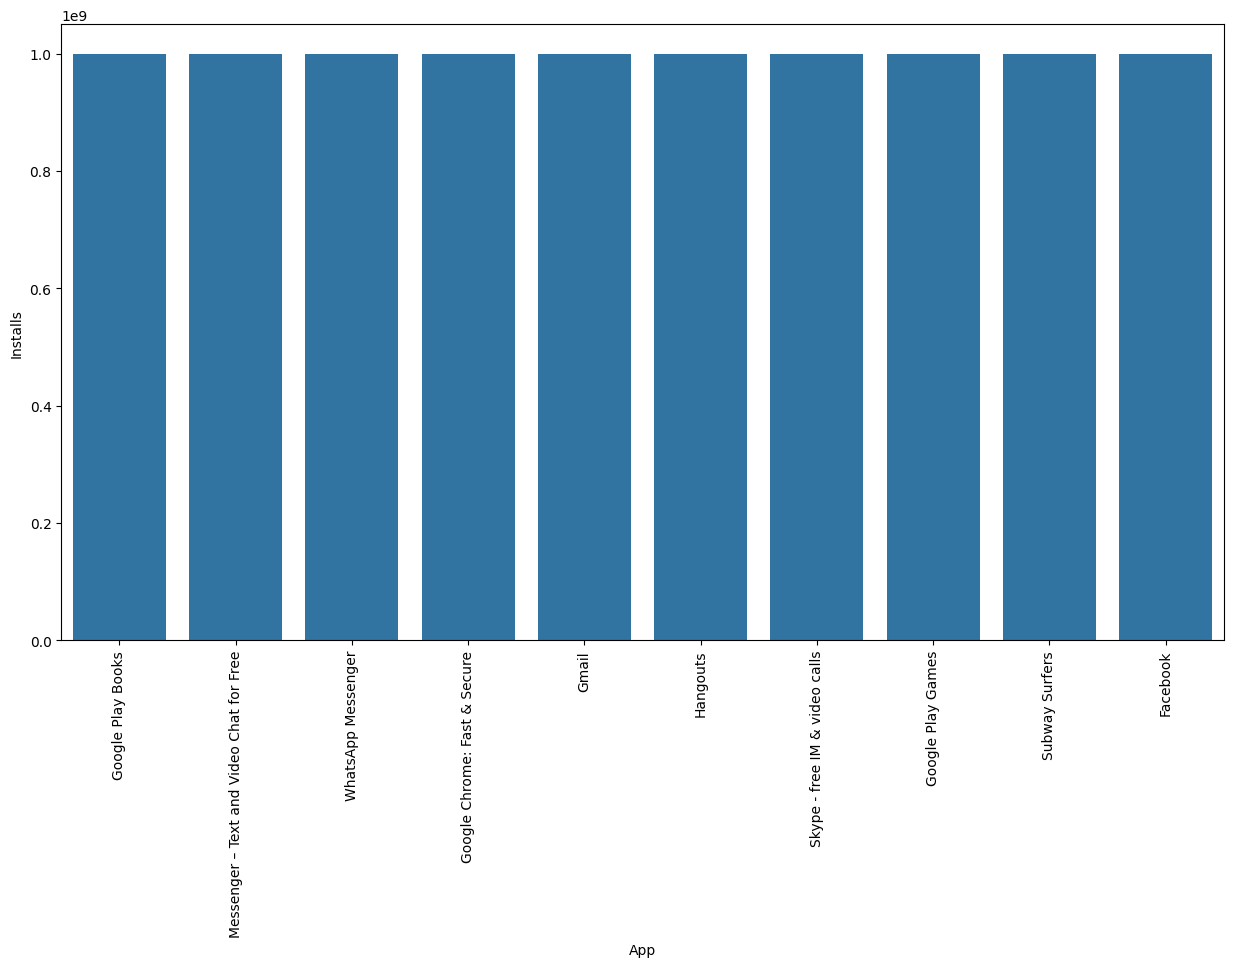

In [126]:
plt.figure(figsize=(15,8))
sns.barplot(data=top_apps,x='App',y='Installs')
plt.xticks(rotation=90)
plt.show()

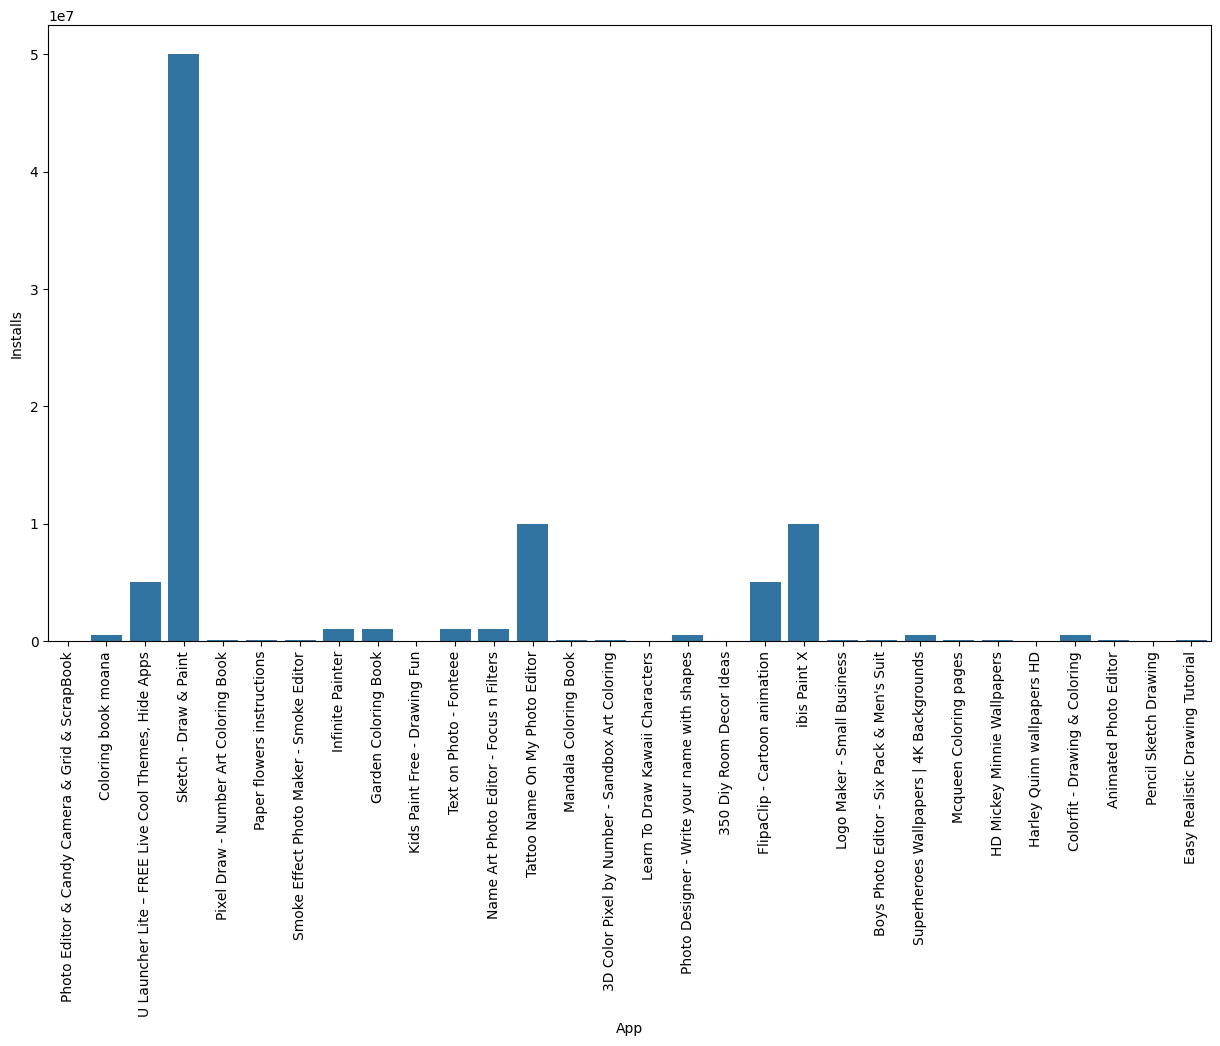

In [129]:
plt.figure(figsize=(15,8))
sns.barplot(data=df.head(30),x='App',y='Installs')
plt.xticks(rotation=90)
plt.show()

WHICH CATEGORIES HAVE THE MOST APPS?

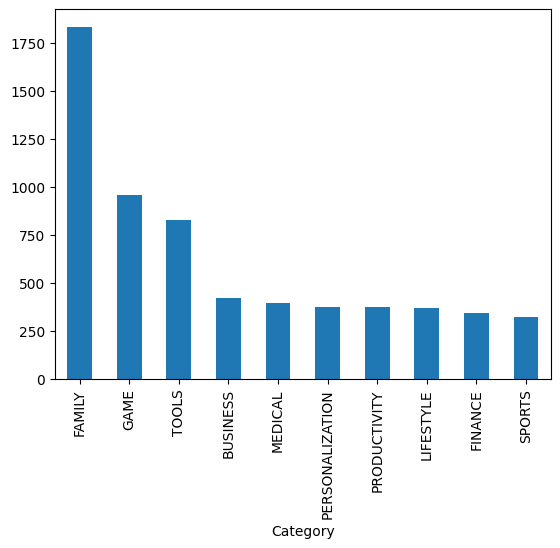

In [130]:
df['Category'].value_counts().head(10).plot(kind="bar")
plt.xticks(rotation=90)
plt.show()

WHICH CATEGORIES HAVE HIGHEST RATING?

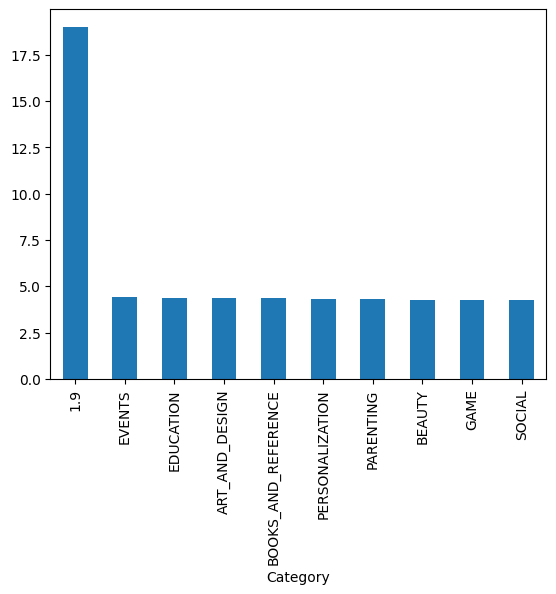

In [131]:
category_rating=df.groupby('Category')['Rating'].mean().sort_values(ascending=False)
category_rating.head(10).plot(kind='bar')
plt.xticks(rotation=90)
plt.show()

In [140]:
df['Reviews']

,Reviews
0,159
1,967
2,87510
3,215644
4,967
...,...
10836,38
10837,4
10838,3
10839,114


DO INSTALLS AND REVIEWS HAS ANY RELATION?

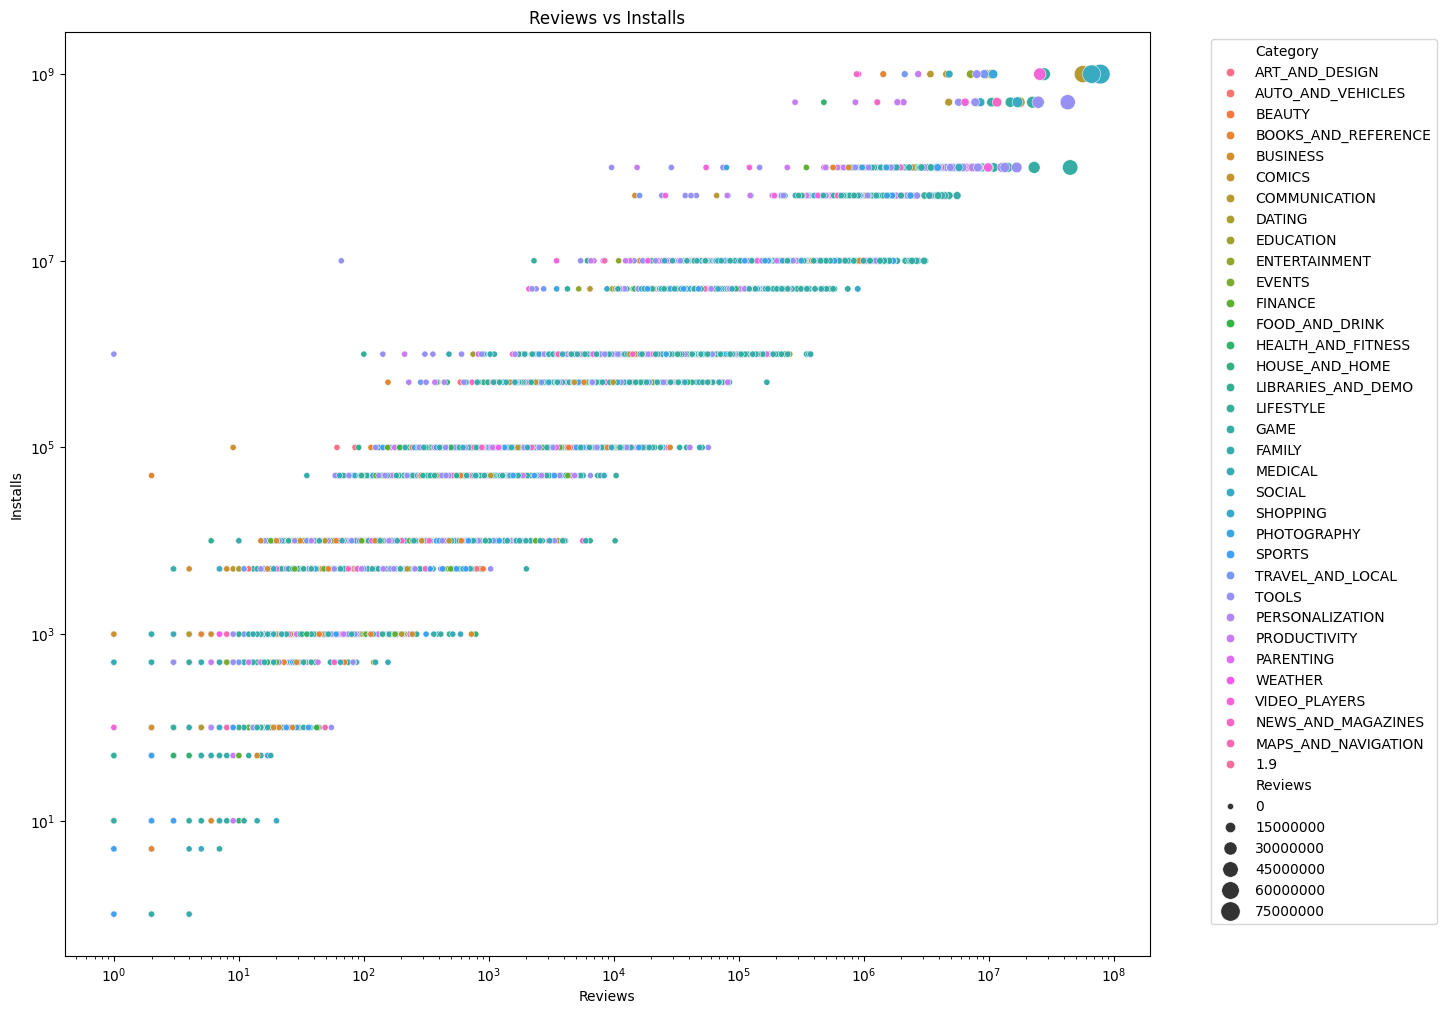

In [169]:

plt.figure(figsize=(14,12))
sns.scatterplot(data=df,x='Reviews',y='Installs',hue='Category',size='Reviews',sizes=(20,200))
plt.xscale('log')
plt.yscale('log')
plt.title('Reviews vs Installs')
plt.xlabel('Reviews')
plt.ylabel('Installs')

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)

#plt.show()


FREE VS PAID APPS

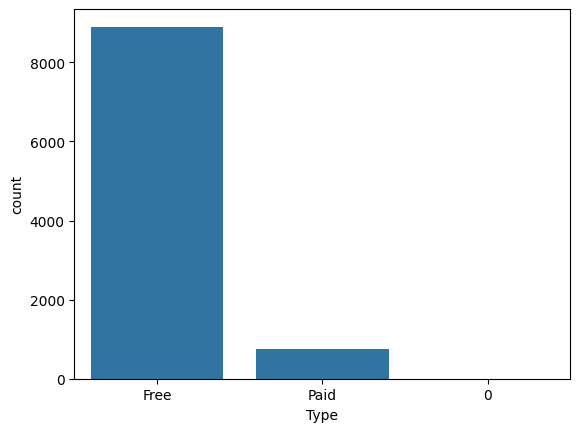

In [170]:
sns.countplot(data=df,x='Type')
plt.show()